In [1]:
!pip install pandas numpy scipy scikit-learn implicit gensim catboost matplotlib seaborn

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/24.4 MB 1.7 MB/s eta 0:00:15
   - -------------------------------------- 1.0/24.4 MB 1.8 MB/s eta 0:00:14
   -- ------------------------------------- 1.6/24.4 MB 1.9 MB/s eta 0:00:13
   --- ------------------------------------ 2.1/24.4 MB 2.0 MB/s eta 0:00:12
   ---- ----------------------------------- 2.6/24.4 MB 2.0 MB/s eta 0:00:11
   ----- ---------------------------------- 3.1/24.4 MB 2.1 MB/s eta 0:00:11
   ------ --------------------------------- 3.7/24.4 MB 2.2 MB/s eta 0:00:10
   ------- -------------------------------- 4.5/24.4 MB 2.3 MB/s eta 0:00:09
   -------- ------------------------------- 5.0/24.4 MB 2.4 MB/s eta 0:00:09
   --------- ------------------------------ 5.8/24.4 MB 2.4 MB/s eta 0:00:08
   ---------- ------

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("odedgolden/movielens-1m-dataset")

print("Path to dataset files:", path)

100%|██████████| 5.83M/5.83M [00:01<00:00, 3.56MB/s]

Extracting files...
Path to dataset files: C:\Users\morro\.cache\kagglehub\datasets\odedgolden\movielens-1m-dataset\versions\1


In [5]:
import os
print(os.listdir(path))

['movies.dat', 'ratings.dat', 'README', 'users.dat']


In [6]:
!pip install implicit -q

In [8]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares

path = path + './'
# Загрузка данных
users = pd.read_csv(path + 'users.dat', sep='::', names=['user_id', 'gender', 'age', 'occupation', 'zip'], engine='python', encoding='ISO-8859-1')
movies = pd.read_csv(path + 'movies.dat', sep='::', names=['movie_id', 'title', 'genres'], engine='python', encoding='ISO-8859-1')
ratings = pd.read_csv(path + 'ratings.dat', sep='::', names=['user_id', 'movie_id', 'rating', 'timestamp'], engine='python', encoding='ISO-8859-1')

# Создаем маппинг для ID (чтобы матрица была плотной, без пропусков в индексах)
user_map = {id: i for i, id in enumerate(users['user_id'].unique())}
movie_map = {id: i for i, id in enumerate(movies['movie_id'].unique())}
inv_movie_map = {v: k for k, v in movie_map.items()}

ratings['u_idx'] = ratings['user_id'].map(user_map)
ratings['m_idx'] = ratings['movie_id'].map(movie_map)

# Матрица взаимодействий (Implicit формат: 1 если есть оценка)
user_item = csr_matrix((np.ones(len(ratings)), (ratings['u_idx'], ratings['m_idx'])))

In [9]:
model_als = AlternatingLeastSquares(factors=64, regularization=0.05, iterations=20, random_state=42)
model_als.fit(user_item)

# Проверка: что рекомендуем пользователю №10?
user_id_test = 10
u_idx = user_map[user_id_test]
ids, scores = model_als.recommend(u_idx, user_item[u_idx], N=50)

recommended_titles = movies[movies['movie_id'].isin([inv_movie_map[i] for i in ids])]['title'].values
print(f"Топ-5 кандидатов для User {user_id_test}: {recommended_titles[:5]}")

c:\Users\morro\anaconda3\envs\autotopic\lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 20/20 [00:00<00:00, 38.11it/s]

Топ-5 кандидатов для User 10: ['American President, The (1995)' 'Babe (1995)' 'Clueless (1995)'
 'Birdcage, The (1996)' 'True Lies (1994)']


In [10]:
import random

def prepare_ranking_data(ratings, movies, users, model_als, n_negatives=10):
    # 1. Позитивные примеры
    data = ratings[['user_id', 'movie_id']].copy()
    data['target'] = 1
    
    # 2. Negative Sampling (очень упрощенно для примера)
    all_movie_ids = movies['movie_id'].unique()
    negative_samples = []
    
    for user_id in data['user_id'].unique():
        watched = set(data[data['user_id'] == user_id]['movie_id'])
        not_watched = list(set(all_movie_ids) - watched)
        
        # Берем n_negatives случайных фильмов, которые юзер не видел
        samples = random.sample(not_watched, min(len(not_watched), n_negatives))
        for m_id in samples:
            negative_samples.append({'user_id': user_id, 'movie_id': m_id, 'target': 0})
            
    full_df = pd.concat([data, pd.DataFrame(negative_samples)])
    
    # 3. Добавляем фичи пользователей
    full_df = full_df.merge(users[['user_id', 'gender', 'age', 'occupation']], on='user_id')
    
    # 4. Добавляем фичи фильмов (извлекаем год из названия)
    movies['year'] = movies['title'].str.extract('(\(\d{4}\))')[0].str.extract('(\d{4})')[0].astype(float)
    full_df = full_df.merge(movies[['movie_id', 'genres', 'year']], on='movie_id')
    
    return full_df

ranking_df = prepare_ranking_data(ratings, movies, users, model_als)

In [11]:
# Извлекаем эмбеддинги из ALS для создания признака "схожесть"
user_factors = model_als.user_factors
item_factors = model_als.item_factors

def get_als_score(row):
    try:
        u_idx = user_map[row['user_id']]
        m_idx = movie_map[row['movie_id']]
        # Скалярное произведение векторов пользователя и фильма
        return np.dot(user_factors[u_idx], item_factors[m_idx])
    except:
        return 0

ranking_df['als_score'] = ranking_df.apply(get_als_score, axis=1)

In [12]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

# Определяем признаки
cat_features = ['gender', 'occupation', 'genres']
features = ['gender', 'age', 'occupation', 'genres', 'year', 'als_score']

X = ranking_df[features]
y = ranking_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем модель
model_ranker = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    verbose=50
)

model_ranker.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 0.4872943	test: 0.4871496	best: 0.4871496 (0)	total: 418ms	remaining: 2m 5s
50:	learn: 0.0830042	test: 0.0820068	best: 0.0820068 (50)	total: 11s	remaining: 53.5s
100:	learn: 0.0824684	test: 0.0816187	best: 0.0816183 (99)	total: 20.6s	remaining: 40.6s
150:	learn: 0.0823385	test: 0.0815555	best: 0.0815555 (149)	total: 29.4s	remaining: 29s
200:	learn: 0.0823238	test: 0.0815501	best: 0.0815501 (200)	total: 36.1s	remaining: 17.8s
250:	learn: 0.0823116	test: 0.0815394	best: 0.0815394 (250)	total: 41.8s	remaining: 8.16s
299:	learn: 0.0823110	test: 0.0815388	best: 0.0815388 (299)	total: 47.2s	remaining: 0us

bestTest = 0.08153882029
bestIteration = 299



In [20]:
def get_final_recommendations(user_id, n_top=10):
    # 1. Retrieval
    u_idx = user_map[user_id]
    candidate_indices, _ = model_als.recommend(u_idx, user_item[u_idx], N=100)
    candidate_ids = [inv_movie_map[i] for i in candidate_indices]
    
    # 2. Подготовка признаков для кандидатов
    candidates_df = pd.DataFrame({'user_id': user_id, 'movie_id': candidate_ids})
    candidates_df = candidates_df.merge(users, on='user_id')
    candidates_df = candidates_df.merge(movies, on='movie_id')
    candidates_df['als_score'] = candidates_df.apply(get_als_score, axis=1)
    
    # 3. Ranking
    preds = model_ranker.predict_proba(candidates_df[features])[:, 1]
    candidates_df['final_score'] = preds
    
    # 4. Сортировка
    return candidates_df.sort_values('final_score', ascending=False).head(n_top)

# Проверяем!
print(get_final_recommendations(user_id=10)[['title', 'genres', 'final_score']])

AttributeError: 'CatBoostRanker' object has no attribute 'predict_proba'

In [21]:
def get_final_recommendations(user_id, n_top=10):
    # 1. Retrieval
    u_idx = user_map[user_id]
    candidate_indices, _ = model_als.recommend(u_idx, user_item[u_idx], N=100)
    candidate_ids = [inv_movie_map[i] for i in candidate_indices]
    
    # 2. Подготовка признаков
    candidates_df = pd.DataFrame({'user_id': user_id, 'movie_id': candidate_ids})
    candidates_df = candidates_df.merge(users, on='user_id')
    candidates_df = candidates_df.merge(movies, on='movie_id')
    
    # Добавляем кросс-фичу, которую использовали при обучении Ranker
    candidates_df['user_genre_interact'] = candidates_df['gender'] + "_" + candidates_df['genres']
    candidates_df['als_score'] = candidates_df.apply(get_als_score, axis=1)
    
    # 3. Ranking (ИСПРАВЛЕНО: используем .predict)
    # Для Ранкера результат predict — это и есть скор для сортировки
    preds = model_ranker.predict(candidates_df[features]) 
    candidates_df['final_score'] = preds
    
    # 4. Сортировка
    return candidates_df.sort_values('final_score', ascending=False).head(n_top)

In [14]:
# Создаем комбинированный признак
ranking_df['user_genre_interact'] = ranking_df['gender'] + "_" + ranking_df['genres']

# Обновляем список категориальных признаков
cat_features = ['gender', 'occupation', 'genres', 'user_genre_interact']
features = ['gender', 'age', 'occupation', 'genres', 'year', 'als_score', 'user_genre_interact']

In [15]:
from catboost import CatBoostRanker

# Сортируем данные по user_id (обязательно для Ranker!)
train_df = ranking_df.sort_values('user_id')

# Создаем объект Pool с указанием групп (группа = user_id)
train_pool = Pool(
    data=train_df[features],
    label=train_df['target'],
    group_id=train_df['user_id'],
    cat_features=cat_features
)

# Параметры для YetiRank
params = {
    'iterations': 500,
    'learning_rate': 0.1,
    'loss_function': 'YetiRank', # Оптимизируем NDCG/MRR
    'train_dir': 'ranking_logs',
}

model_ranker = CatBoostRanker(**params)
model_ranker.fit(train_pool, verbose=50)

Groupwise loss function. OneHotMaxSize set to 10
0:	total: 1.25s	remaining: 10m 25s
50:	total: 52.8s	remaining: 7m 45s
100:	total: 1m 43s	remaining: 6m 49s
150:	total: 2m 33s	remaining: 5m 54s
200:	total: 3m 23s	remaining: 5m 2s
250:	total: 4m 13s	remaining: 4m 11s
300:	total: 5m 5s	remaining: 3m 21s
350:	total: 5m 57s	remaining: 2m 31s
400:	total: 6m 47s	remaining: 1m 40s
450:	total: 7m 38s	remaining: 49.8s
499:	total: 8m 28s	remaining: 0us


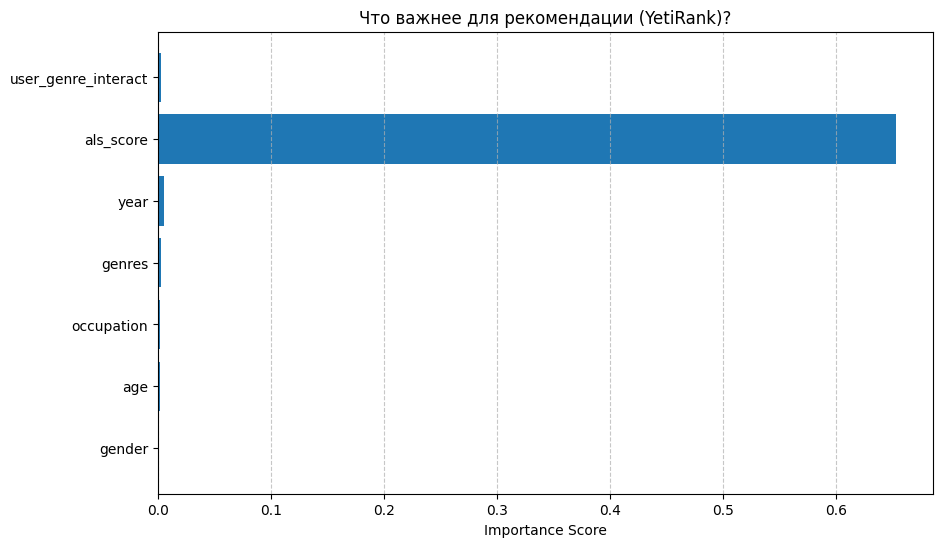

In [17]:
# Передай сюда свой train_pool или другой объект Pool
importances = model_ranker.get_feature_importance(train_pool)

# Теперь визуализация сработает
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Importance Score")
plt.title("Что важнее для рекомендации (YetiRank)?")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [22]:
import numpy as np

def ndcg_at_k(predicted_ids, true_watched_ids, k=10):
    # Оставляем только топ-K
    predicted_ids = predicted_ids[:k]
    
    # Считаем DCG
    dcg = 0.0
    for i, p_id in enumerate(predicted_ids):
        if p_id in true_watched_ids:
            # i+2 потому что индекс начинается с 0, а формула с 1 (log2(1+1))
            dcg += 1.0 / np.log2(i + 2)
            
    # Считаем Ideal DCG (если бы все реальные просмотры были в топе)
    idcg = 0.0
    n_relevant = min(len(true_watched_ids), k)
    for i in range(n_relevant):
        idcg += 1.0 / np.log2(i + 2)
        
    return dcg / idcg if idcg > 0 else 0.0

# Пример расчета:
# Предположим, для пользователя 10:
true_watched = set(ratings[ratings['user_id'] == 10]['movie_id'])
recommendations = get_final_recommendations(user_id=10, n_top=10)['movie_id'].tolist()

score = ndcg_at_k(recommendations, true_watched, k=10)
print(f"NDCG@10 для пользователя 10: {score:.4f}")

NDCG@10 для пользователя 10: 0.0000


In [23]:
def evaluate_system(test_user_ids, k=10):
    als_scores = []
    hybrid_scores = []
    
    for u_id in test_user_ids:
        # Реальные просмотры пользователя для валидации
        true_watched = set(ratings[ratings['user_id'] == u_id]['movie_id'])
        if not true_watched: continue
            
        # 1. Тест только ALS
        u_idx = user_map[u_id]
        # Получаем чуть больше, чтобы сравнение было честным (топ-10)
        als_candidate_indices, _ = model_als.recommend(u_idx, user_item[u_idx], N=k)
        als_recs = [inv_movie_map[i] for i in als_candidate_indices]
        als_scores.append(ndcg_at_k(als_recs, true_watched, k=k))
        
        # 2. Тест ALS + CatBoost (наша функция из Шага 6)
        hybrid_recs_df = get_final_recommendations(u_id, n_top=k)
        hybrid_recs = hybrid_recs_df['movie_id'].tolist()
        hybrid_scores.append(ndcg_at_k(hybrid_recs, true_watched, k=k))
        
    return np.mean(als_scores), np.mean(hybrid_scores)

# Запускаем на случайной выборке из 100 юзеров
test_users = np.random.choice(users['user_id'].unique(), 100)
mean_als, mean_hybrid = evaluate_system(test_users)

print(f"Результаты эксперимента:")
print(f"Mean NDCG@{10} (Только ALS): {mean_als:.4f}")
print(f"Mean NDCG@{10} (ALS + CatBoost): {mean_hybrid:.4f}")
print(f"Прирост: {((mean_hybrid - mean_als) / mean_als) * 100:.2f}%")

Результаты эксперимента:
Mean NDCG@10 (Только ALS): 0.0093
Mean NDCG@10 (ALS + CatBoost): 0.0096
Прирост: 2.92%
